
# Modelos Lineares Generalizados - Distribuições de Probabilidade

Este notebook apresenta as principais distribuições de probabilidade utilizadas em **Modelos Lineares Generalizados (GLM)**, explorando:

- **Teoria**: fórmula da função de probabilidade/densidade, parâmetros e propriedades.
- **Identificação**: o que observar em análises exploratórias para verificar se os dados seguem determinada distribuição.
- **Exemplos práticos**: geração de dados simulados, gráficos e medidas descritivas.

As distribuições abordadas:

1. Normal
2. Normal Inversa (*Inverse Gaussian*)
3. Gama (e conexões com Qui-quadrado e Exponencial)
4. Poisson
5. Binomial
6. Binomial Negativa
7. Exponencial
8. Qui-quadrado


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
np.random.seed(42)

def plot_distribution(data, dist_name, bins=50, fit_dist=None):
    plt.figure(figsize=(8,5))
    sns.histplot(data, bins=bins, kde=True, stat="density", color="skyblue")
    if fit_dist:
        x = np.linspace(min(data), max(data), 200)
        plt.plot(x, fit_dist.pdf(x), 'r-', lw=2, label=f"Ajuste {fit_dist.dist.name}")
        plt.legend()
    plt.title(f"Distribuição: {dist_name}")
    plt.show()


## 1. Distribuição Normal
**PDF:**
$$
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$
**Parâmetros:** média $\mu$, variância $\sigma^2$  
**Propriedades:** simétrica, média=mediana=moda, usada no TCL  
**Identificação visual:** histograma em forma de sino


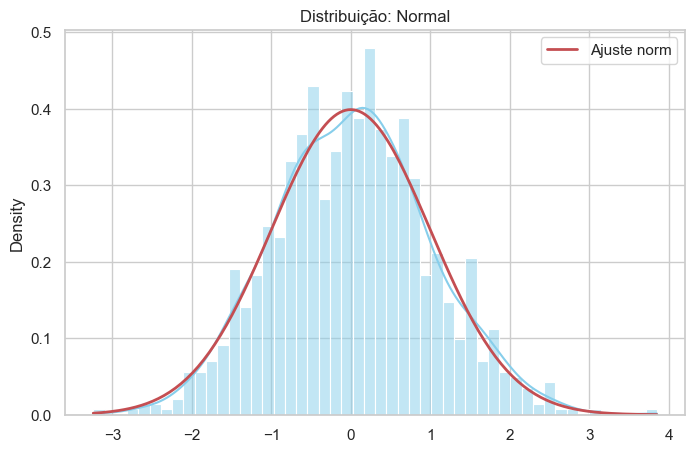

DescribeResult(nobs=np.int64(1000), minmax=(np.float64(-3.2412673400690726), np.float64(3.852731490654721)), mean=np.float64(0.01933205582232549), variance=np.float64(0.9588638535851025), skewness=np.float64(0.11680083110533511), kurtosis=np.float64(0.06620589292148393))


In [2]:
mu, sigma = 0, 1
normal_data = np.random.normal(mu, sigma, 1000)
plot_distribution(normal_data, "Normal", fit_dist=stats.norm(loc=mu, scale=sigma))
print(stats.describe(normal_data))


## 2. Distribuição Normal Inversa (*Inverse Gaussian*)
**PDF:**
$$
f(x; \mu, \lambda) = \left(\frac{\lambda}{2\pi x^3}\right)^{1/2} e^{-\frac{\lambda(x - \mu)^2}{2\mu^2 x}}
$$
**Parâmetros:** $\mu$ média, $\lambda$ forma  
**Propriedades:** positiva, assimétrica à direita  
**Identificação:** cauda longa positiva


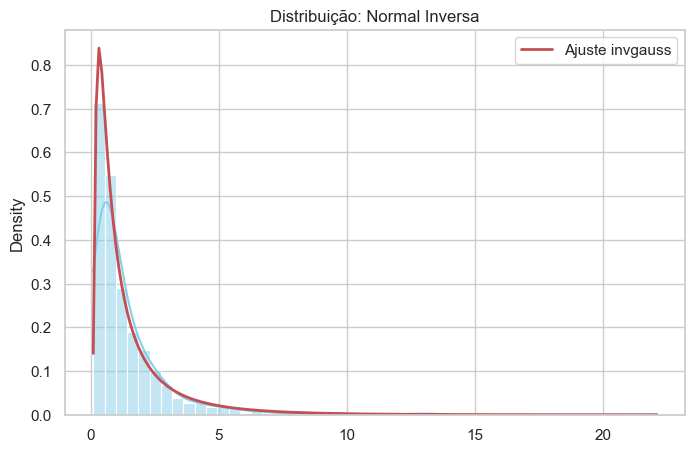

DescribeResult(nobs=np.int64(1000), minmax=(np.float64(0.09607915249376475), np.float64(22.100341073157477)), mean=np.float64(1.4318200652055466), variance=np.float64(3.1757928337795316), skewness=np.float64(4.176427744380859), kurtosis=np.float64(28.401924487828044))


In [3]:
mu_inv, lambda_inv = 3, 2
invgauss_data = stats.invgauss(mu=mu_inv/lambda_inv).rvs(1000)
plot_distribution(invgauss_data, "Normal Inversa", fit_dist=stats.invgauss(mu=mu_inv/lambda_inv))
print(stats.describe(invgauss_data))


## 3. Distribuição Gama e conexões

**PDF:**
$$
f(x; k, \theta) = \frac{x^{k-1} e^{-x/\theta}}{\Gamma(k) \theta^k}
$$
**Parâmetros:** $k$ forma, $\theta$ escala  
**Propriedades:** positiva, assimétrica positiva, média=$k\theta$, var=$k\theta^2$  

**Conexões importantes:**
- **Exponencial**: caso especial da Gama com $k = 1$
- **Qui-quadrado**: caso especial da Gama com $k = \nu/2$ e $\theta = 2$, onde $\nu$ são os graus de liberdade

**Identificação:** assimetria diminui com $k$ maior


C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


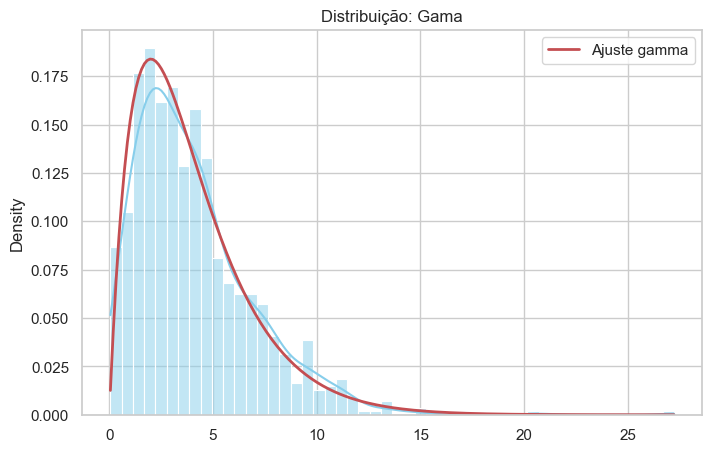

C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


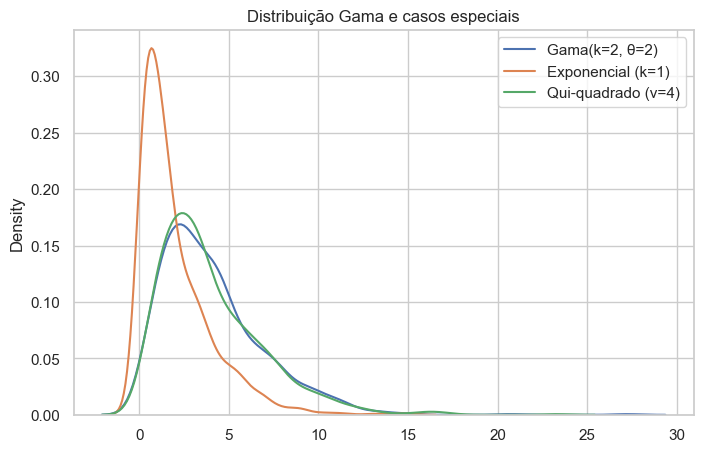

In [4]:
shape, scale = 2, 2
gamma_data = np.random.gamma(shape, scale, 1000)
plot_distribution(gamma_data, "Gama", fit_dist=stats.gamma(a=shape, scale=scale))

# Comparação com Exponencial e Qui-quadrado como casos especiais
exp_data = np.random.exponential(scale, 1000)
chi_data = np.random.chisquare(df=4, size=1000)  # k=2, theta=2
plt.figure(figsize=(8,5))
sns.kdeplot(gamma_data, label=f"Gama(k={shape}, θ={scale})")
sns.kdeplot(exp_data, label="Exponencial (k=1)")
sns.kdeplot(chi_data, label="Qui-quadrado (ν=4)")
plt.title("Distribuição Gama e casos especiais")
plt.legend()
plt.show()


## 4. Distribuição de Poisson
**PMF:**
$$
P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}
$$
**Parâmetro:** $\lambda$ taxa  
**Propriedades:** média = variância = $\lambda$  
**Identificação:** dados de contagem com média e variância próximas


C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


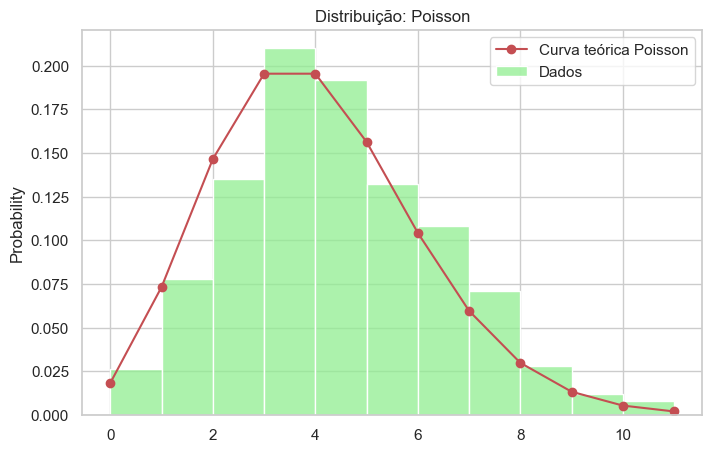

Média: 3.965  Variância: 4.131774999999999


In [5]:
lam = 4
poisson_data = np.random.poisson(lam, 1000)
values, counts = np.unique(poisson_data, return_counts=True)
probs = stats.poisson.pmf(values, mu=lam)

plt.figure(figsize=(8,5))
sns.histplot(poisson_data, bins=range(min(poisson_data), max(poisson_data)+1), stat="probability", color="lightgreen", label="Dados")
plt.plot(values, probs, 'ro-', label="Curva teórica Poisson")
plt.title("Distribuição: Poisson")
plt.legend()
plt.show()

print("Média:", np.mean(poisson_data), " Variância:", np.var(poisson_data))


## 5. Distribuição Binomial
**PMF:**
$$
P(X = k) = {n \choose k} p^k (1-p)^{n-k}
$$
**Parâmetros:** $n$ tentativas, $p$ probabilidade sucesso  
**Propriedades:** média=$np$, var=$np(1-p)$  
**Identificação:** contagem limitada entre 0 e $n$


C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


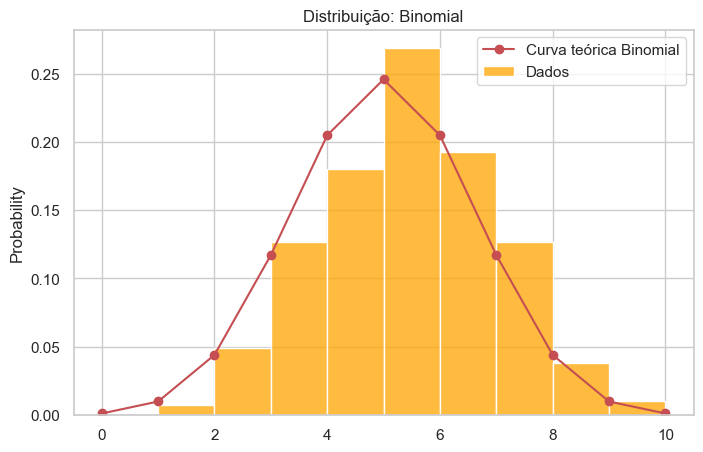

Média: 4.993  Variância: 2.452951


In [6]:
n, p = 10, 0.5
binomial_data = np.random.binomial(n, p, 1000)
plt.figure(figsize=(8,5))
sns.histplot(binomial_data, bins=range(min(binomial_data), max(binomial_data)+1), stat="probability", color="orange", label="Dados")
plt.plot(range(n+1), stats.binom.pmf(range(n+1), n, p), 'ro-', label="Curva teórica Binomial")
plt.title("Distribuição: Binomial")
plt.legend()
plt.show()
print("Média:", np.mean(binomial_data), " Variância:", np.var(binomial_data))


### Teorema Central do Limite (TCL)
O **TCL** afirma que, sob certas condições, a soma (ou média) de um grande número de variáveis aleatórias independentes e identicamente distribuídas tende a seguir uma **distribuição normal**, independentemente da distribuição original.

**Implicações:**
- Poisson com $\lambda$ grande se aproxima da Normal
- Binomial com $n$ grande e $p$ não muito próximo de 0 ou 1 também se aproxima da Normal



## 6. Distribuição Binomial Negativa
**PMF:**
$$
P(X = k) = {k + r - 1 \choose k} (1-p)^r p^k
$$
**Parâmetros:** $r$ falhas até parar, $p$ probabilidade sucesso  
**Propriedades:** média=$\frac{pr}{1-p}$, var=$\frac{pr}{(1-p)^2}$  
**Identificação:** contagem com superdispersão


C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


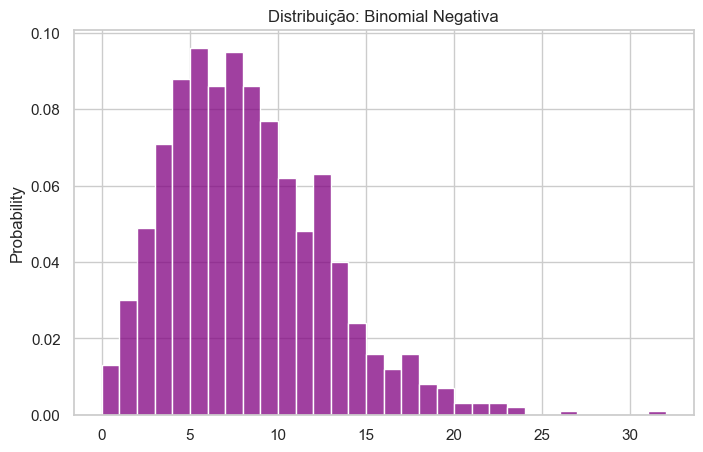

Média: 7.769  Variância: 19.499639000000002


In [7]:
r, p = 5, 0.4
nbinom_data = np.random.negative_binomial(r, p, 1000)
plt.figure(figsize=(8,5))
sns.histplot(nbinom_data, bins=range(min(nbinom_data), max(nbinom_data)+1), stat="probability", color="purple")
plt.title("Distribuição: Binomial Negativa")
plt.show()
print("Média:", np.mean(nbinom_data), " Variância:", np.var(nbinom_data))


## 7. Distribuição Exponencial
**PDF:**
$$
f(x; \lambda) = \lambda e^{-\lambda x}
$$
**Parâmetro:** $\lambda$ taxa  
**Propriedades:** média=$1/\lambda$, var=$1/\lambda^2$  
**Identificação:** positiva, decaimento exponencial


C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


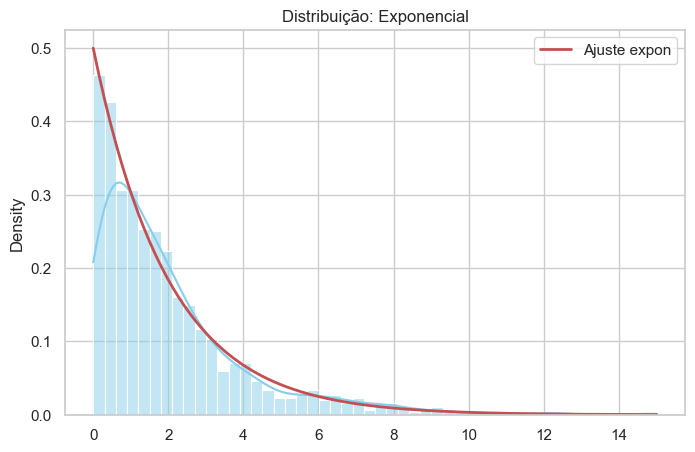

DescribeResult(nobs=1000, minmax=(0.0021842743754487202, 15.013087253207887), mean=1.9738776044797572, variance=4.0668212330382945, skewness=2.105792989405422, kurtosis=6.171470114015854)


In [8]:
scale_exp = 2
exp_data = np.random.exponential(scale_exp, 1000)
plot_distribution(exp_data, "Exponencial", fit_dist=stats.expon(scale=scale_exp))
print(stats.describe(exp_data))


## 8. Distribuição Qui-quadrado
**PDF:**
$$
f(x; k) = \frac{1}{2^{k/2}\Gamma(k/2)} x^{k/2 - 1} e^{-x/2}
$$
**Parâmetro:** $k$ graus de liberdade  
**Propriedades:** média=$k$, var=$2k$  
**Identificação:** positiva, assimetria diminui com $k$


C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


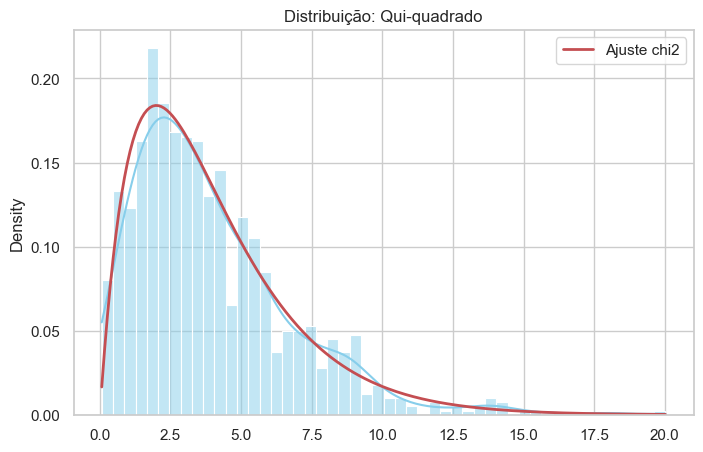

DescribeResult(nobs=1000, minmax=(0.068515467921686, 20.021284702121193), mean=3.959944764731398, variance=8.140298281358906, skewness=1.472817053490274, kurtosis=3.185174006951084)


In [9]:
df_chi = 4
chi_data = np.random.chisquare(df_chi, 1000)
plot_distribution(chi_data, "Qui-quadrado", fit_dist=stats.chi2(df=df_chi))
print(stats.describe(chi_data))